# Uplift Modeling em Marketing — Notebook 2: Baseline (Propensity Model)

> Continuação de `01_Framing_EDA_PT.ipynb`. Este notebook não compartilha o kernel do
> anterior — recarrega abaixo, de forma barata, exatamente o necessário (dados brutos e
> as constantes de braço/tratamento). Nenhum resultado de EDA é recalculado ou
> reapresentado; isso já está no notebook 1.

---

## Índice

- [Setup — retomando de S1/S2](#setup)
- [Seção 3 — Baseline: propensity model](#s3)
    - [3.1 Preparação: splits e tratamento pooled](#s3-1)
    - [3.2 Baseline de propensão: $P(\text{visit}=1 \mid X)$ no braço tratado](#s3-2)
    - [3.3 Avaliação do baseline com métricas de uplift (validação)](#s3-3)
    - [3.4 T-learner rápido: referência provisória de uplift](#s3-4)
    - [3.5 Propensão vs. uplift: os dois rankings concordam?](#s3-5)
    - [3.6 Regra de confirmação (escrita antes do teste selado ser aberto)](#s3-6)
    - [Síntese da Seção 3](#s3-summary)

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

# Bootstrap de path: permite `from src...` a partir de notebooks/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SEED
from src.i18n import make_lang
from src.viz import apply_plot_style

np.random.seed(SEED)
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 4)
warnings.filterwarnings('ignore', category=FutureWarning)
# Modelo de propensão interno dos meta-learners do causalml (S4) usa um
# solver elastic-net que não converge dentro do max_iter padrão em bases
# pequenas — não afeta o resultado (é só o nuisance model), mas polui a saída.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Idioma canônico deste notebook é PT — passthrough, sem chamada de rede.
# A edição EN (futura) troca só esta linha para make_lang('en').
lang = make_lang('pt')

apply_plot_style()

In [2]:
# Stack causal (verifique a instalação antes da primeira run)
# pip install econml causalml scikit-uplift shap mlflow

# Meta-learners e árvores de uplift
from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor, BaseRRegressor
from causalml.inference.tree import UpliftRandomForestClassifier

# Causal Forest com intervalos de confiança
from econml.dml import CausalForestDML
from econml.metalearners import TLearner, SLearner, XLearner

# Avaliação
from sklift.metrics import uplift_at_k, qini_auc_score, uplift_auc_score

from src.compat import patch_sklearn_matplotlib_support
patch_sklearn_matplotlib_support()
from sklift.viz import plot_qini_curve, plot_uplift_curve

# Interpretabilidade
import shap

Failed to import duecredit due to No module named 'duecredit'


In [3]:
from src.config import ARTIFACTS_DIR, RETRAIN

ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

# MLflow — ajuste o URI conforme seu setup Windows
# mlflow.set_tracking_uri('file:///C:/path/to/mlruns')
# mlflow.set_experiment('uplift_hillstrom')

<a id="setup"></a>

## Setup — retomando de S1/S2

Recarregamos aqui o necessário para a Seção 3: os dados brutos e as constantes de
braço/tratamento (`ARMS`, `TREATMENT`). Nada aqui foi computado antes — é o mesmo
carregamento determinístico de `01_Framing_EDA_PT.ipynb`.

In [4]:
from src.config import ARMS, TREATMENT_COL as TREATMENT
from src.data import load_hillstrom

df = load_hillstrom()

<a id='s3'></a>
<a id="s3"></a>

# Seção 3 — Baseline: propensity model

**Objetivos:**

1. Estabelecer a régua que este projeto existe para bater: um modelo de resposta $P(\text{visit}=1 \mid X)$ treinado **apenas sobre o braço tratado** — é exatamente o que marketing faz na prática quando rankeia quem tratar sem uma noção explícita de efeito incremental.
2. Ranquear a base de validação por essa probabilidade e avaliá-la com as **mesmas métricas de uplift** que decidirão o vencedor em S6 (Qini, AUUC) — para que a comparação com os meta-learners de S4-S5 seja direta.
3. Comparar esse ranking com um T-learner rápido e não tunado (referência provisória de efeito incremental) via correlação de Spearman. Hipótese de trabalho: **os dois rankings devem concordar pouco** — ranquear por probabilidade de resposta e ranquear por efeito incremental do tratamento são, conceitualmente, perguntas diferentes.
4. Escrever, **antes de qualquer número do teste selado existir**, a regra de confirmação que será aplicada em S6 (Regra Absoluta #2 do protocolo deste projeto).

**Tratamento a partir daqui (S3–S6): pooled.** $T=1$ para qualquer braço de e-mail (Mens ou Womens), $T=0$ para No E-Mail — 42.667 tratados vs. 21.333 controles. A separação por braço individual só volta em S8, para a política de atribuição em 3 vias.

**O que NÃO acontece nesta seção.** Nenhuma célula abaixo toca no conjunto de teste selado (`src/splits.py::load_sealed_test`), nem faz `predict` sobre ele. Apenas treino e validação são usados.

<a id='s3-1'></a>
<a id="s3-1"></a>

## 3.1 Preparação: splits e tratamento pooled

Materializamos agora os conjuntos de treino e validação via `make_splits` — S3–S6 usam só esses dois; o teste fica selado em disco até S6. O tratamento pooled (`treatment`: 1 = qualquer e-mail, 0 = No E-Mail) é adicionado via `add_pooled_treatment`, sem alterar a coluna `segment` original — ela volta a ser usada em S8, para a política de atribuição em 3 vias.

In [5]:
from src.config import POOLED_TREATMENT_COL, PRIMARY_OUTCOME
from src.data import add_pooled_treatment
from src.splits import make_splits

df_pooled = add_pooled_treatment(df)
split_idx = make_splits(df_pooled)
train_df = df_pooled.loc[split_idx['train_idx']].copy()
val_df = df_pooled.loc[split_idx['val_idx']].copy()

labels = lang({'header': 'Tamanho das partições (teste permanece selado)'})
print(f"{labels['header']}:")
print(f"  Treino:     {len(train_df):>6} linhas | tratados: {int(train_df[POOLED_TREATMENT_COL].sum()):>6}")
print(f"  Validação:  {len(val_df):>6} linhas | tratados: {int(val_df[POOLED_TREATMENT_COL].sum()):>6}")

Tamanho das partições (teste permanece selado):
  Treino:      38400 linhas | tratados:  25617
  Validação:   12800 linhas | tratados:   8538


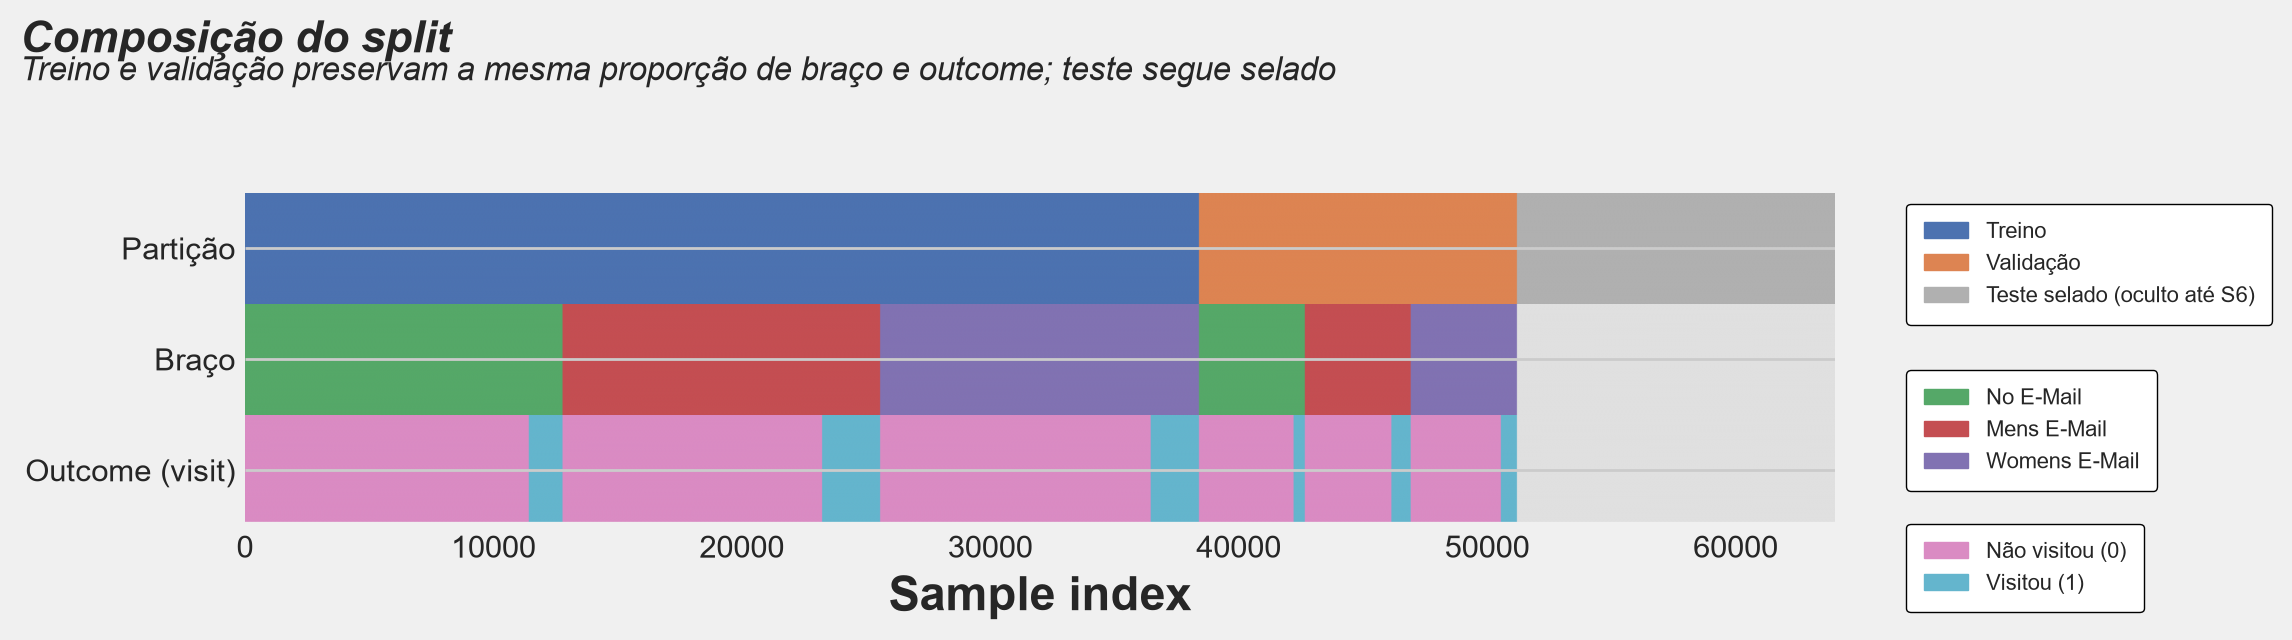

In [6]:
from src.viz import plot_split_overview

labels = lang({
    'partition_row': 'Partição',
    'arm_row': 'Braço',
    'outcome_row': 'Outcome (visit)',
    'train': 'Treino',
    'val': 'Validação',
    'sealed': 'Teste selado (oculto até S6)',
    'outcome_neg': 'Não visitou (0)',
    'outcome_pos': 'Visitou (1)',
    'title': 'Composição do split',
    'subtitle': 'Treino e validação preservam a mesma proporção de braço e outcome; teste segue selado',
})
n_test = len(df_pooled) - len(train_df) - len(val_df)
fig, ax = plot_split_overview(
    train_df, val_df, n_test, TREATMENT, ARMS, PRIMARY_OUTCOME, labels,
    title=labels['title'], subtitle=labels['subtitle'],
)
plt.show()

**Leitura do gráfico.** Treino e validação estão ordenados por (braço, outcome) só para tornar visíveis, em blocos, as proporções relativas de cada combinação — a ordem não tem significado temporal (o dataset não é uma série temporal). O bloco cinza do teste selado aparece só em tamanho: nenhuma composição de braço ou outcome é revelada até a Seção 6, por disciplina do protocolo. A semelhança visual entre os blocos de treino e validação é o retrato gráfico da estratificação (braço × visit) já verificada por teste automatizado em `tests/test_suite.py`.

<a id='s3-2'></a>
<a id="s3-2"></a>

## 3.2 Baseline de propensão: $P(\text{visit}=1 \mid X)$ no braço tratado

O baseline treina um classificador de resposta **só com as linhas tratadas** — nunca vê o braço de controle. Ele responde "quem, entre os tratados, tem maior probabilidade de visitar o site?", que é a pergunta que propensity/response modeling responde na prática de marketing. Não é uma pergunta causal: nada nesse modelo separa "ia visitar de qualquer jeito" de "visitou por causa do e-mail".

Usamos LightGBM — a mesma classe de modelo que vai ancorar os quatro meta-learners de S4. A escolha é deliberada: se o baseline perder para os meta-learners, queremos que a diferença venha da **estratégia de targeting** (propensão vs. uplift), não da capacidade do modelo.

In [7]:
from src.learners import fit_propensity_baseline, predict_propensity_score

propensity_model = fit_propensity_baseline(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME)
val_df['propensity_score'] = predict_propensity_score(propensity_model, val_df)
val_df[['propensity_score']].describe()

,propensity_score
count,12800.0000
mean,0.1648
std,0.0714
min,0.0203
25%,0.1155
50%,0.1585
75%,0.2050
max,0.5836


<a id='s3-3'></a>
<a id="s3-3"></a>

## 3.3 Avaliação do baseline com métricas de uplift (validação)

O baseline não estima efeito incremental — mas para comparar com os modelos de S4-S5 em pé de igualdade, avaliamos seu **ranking** com as mesmas métricas que vão decidir o vencedor em S6: Qini AUC, uplift AUC (AUUC) e uplift@30%. Isso é possível porque essas métricas não exigem que o score seja um CATE — só exigem um ranking; um score de propensão alto é tratado, para efeito da métrica, como "prioridade alta de tratamento".

In [8]:
from src.evaluation import evaluate_ranking

baseline_metrics = evaluate_ranking(
    val_df[PRIMARY_OUTCOME].values, val_df['propensity_score'].values, val_df[POOLED_TREATMENT_COL].values,
)
print(baseline_metrics)

{'qini_auc': np.float64(0.03951007656729185), 'uplift_auc': np.float64(0.02347259841903208), 'uplift_at_30pct': np.float64(0.09228755179338571)}


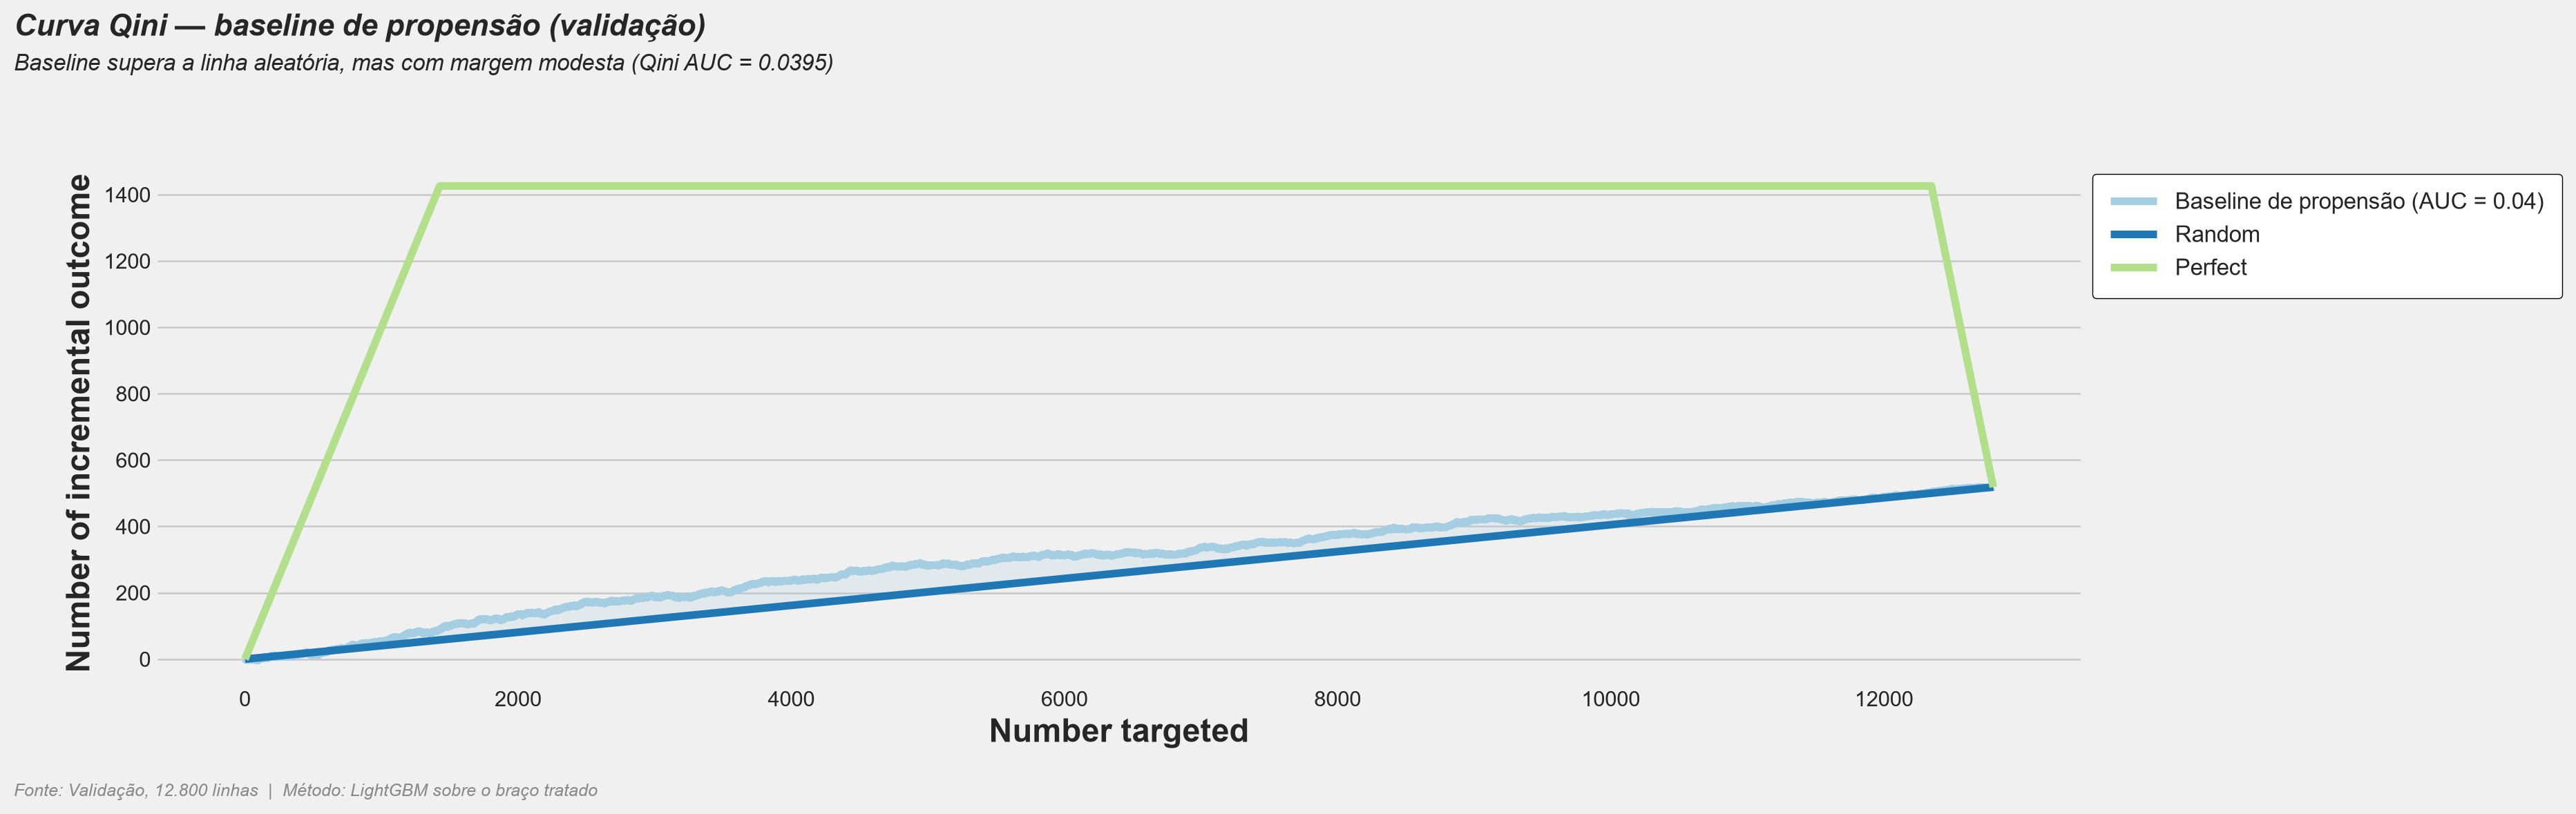

In [9]:
from src.viz import add_chart_footer, add_chart_header

labels = lang({
    'title': 'Curva Qini — baseline de propensão (validação)',
    'series_name': 'Baseline de propensão',
    'subtitle': 'Baseline supera a linha aleatória, mas com margem modesta (Qini AUC = 0.0395)',
})
qini_disp = plot_qini_curve(
    val_df[PRIMARY_OUTCOME].values, val_df['propensity_score'].values, val_df[POOLED_TREATMENT_COL].values,
    perfect=True, name=labels['series_name'],
)
add_chart_header(qini_disp.figure_, title=labels['title'], subtitle=labels['subtitle'])
add_chart_footer(qini_disp.figure_, data_source='Validação, 12.800 linhas',
                  method='LightGBM sobre o braço tratado')
qini_disp.figure_.subplots_adjust(top=0.78, bottom=0.15)
plt.show()

**Leitura.** Na validação (12.800 linhas, 8.538 tratadas), o baseline de propensão obtém Qini AUC = 0.0395, uplift AUC (AUUC) = 0.0235 e uplift@30% = +0.0923 — ou seja, tratando os 30% do topo do ranking por propensão, a taxa de visita entre tratados e controle nesse subconjunto difere em ~9.2pp a mais do que se observaria tratando aleatoriamente. Esses três números são a régua que os meta-learners de S4 e os modelos diretos de S5 precisam bater. Nesta seção eles ainda não têm com o que ser comparados formalmente — isso, com intervalos de confiança, é trabalho de S6.

<a id='s3-4'></a>
<a id="s3-4"></a>

## 3.4 T-learner rápido: referência provisória de uplift

Para checar se o ranking por propensão concorda com um ranking por efeito incremental, precisamos de *algum* estimador de CATE — mesmo que provisório. Ajustamos um T-learner simples (dois LightGBM independentes, um por braço, sem tuning) só para esta checagem. A versão definitiva, tunada e comparada formalmente aos demais meta-learners, é trabalho de S4 — este modelo aqui não entra nessa comparação.

In [10]:
from src.learners import fit_t_learner_quick, predict_t_learner_uplift

t_learner_models = fit_t_learner_quick(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME)
val_df['t_learner_uplift'] = predict_t_learner_uplift(t_learner_models, val_df)
val_df[['t_learner_uplift']].describe()

,t_learner_uplift
count,12800.0000
mean,0.0602
std,0.0692
min,-0.5835
25%,0.0265
50%,0.0605
75%,0.0980
max,0.5499


<a id='s3-5'></a>
<a id="s3-5"></a>

## 3.5 Propensão vs. uplift: os dois rankings concordam?

Se o ranking por propensão e o ranking por uplift (T-learner) fossem essencialmente a mesma coisa, não haveria motivo para este projeto existir — bastaria continuar rankeando por probabilidade de resposta. A correlação de Spearman entre os dois scores mede diretamente essa sobreposição.

In [11]:
from src.evaluation import spearman_ranking_correlation

rank_corr = spearman_ranking_correlation(val_df['propensity_score'], val_df['t_learner_uplift'])
print(rank_corr)

{'spearman_corr': np.float64(0.4437211883670506), 'p_value': np.float64(0.0)}


**Leitura.** A correlação de Spearman entre o score de propensão e o uplift do T-learner é $\rho = 0.444$ ($p \approx 0$, o que não surpreende com $n = 12.800$). Isso é **mais alto do que a hipótese de trabalho antecipava** — os dois rankings não são independentes, e ranquear por propensão de fato carrega algum sinal sobre efeito incremental (plausível: neste dataset, clientes com maior probabilidade basal de visitar também tendem a reagir mais ao estímulo). Ainda assim, $\rho = 0.444$ está longe de indicar que os dois rankings são intercambiáveis — mais da metade da variação de ranking não é compartilhada entre as duas abordagens, e é exatamente nessa divergência que uplift modeling pode capturar valor que propensity modeling não captura.

Vale notar que o T-learner rápido (sem tuning) produziu uplift estimado com cauda negativa longa (mínimo -0.58). Não interpretamos isso como evidência de Sleeping Dogs nesta seção — é um estimador provisório e conhecidamente ruidoso; a análise de heterogeneidade fica para S7.

<a id='s3-6'></a>
<a id="s3-6"></a>

## 3.6 Regra de confirmação (escrita antes do teste selado ser aberto)

Fixamos agora, antes de qualquer número do teste selado existir, a regra que será aplicada em S6 para decidir se o modelo vencedor da validação é confirmado no teste.

> ### Regra de confirmação para S6
> O modelo vencedor da validação (maior Qini AUC entre S3–S5) é **confirmado** no teste selado se, e somente se, todas as condições abaixo se sustentarem:
> 1. Sua Qini no teste é **positiva**;
> 2. O intervalo de confiança de bootstrap (95%) da Qini no teste **não inclui zero**;
> 3. Sua Qini no teste **supera** a Qini do baseline de propensão (Seção 3.3), medida no mesmo teste.
>
> Se qualquer condição falhar, o resultado é **"não confirmado"** — e será reportado exatamente assim, sem ajuste de protocolo (Regra Absoluta #6: resultado negativo é resultado).

Esta regra não será revisada em S6, independentemente do que os resultados da validação (S4-S5) sugerirem.

<a id="s3-summary"></a>

### Síntese da Seção 3

| Item | Resultado |
|---|---|
| Baseline de propensão — Qini AUC (validação) | 0.0395 |
| Baseline de propensão — uplift@30% (validação) | +9.2pp |
| Correlação (Spearman) propensão × T-learner rápido | 0.444 ($p \approx 0$) |
| Regra de confirmação para S6 | Escrita na Seção 3.6, antes de qualquer resultado de teste |

O baseline de propensão está estabelecido como a régua a bater. A correlação moderada com o T-learner confirma que propensão e uplift são sinais relacionados, mas não equivalentes — abrindo espaço real para os meta-learners de S4 superarem esse baseline nas métricas de uplift, sem que isso seja garantido.

**Próximo:** [Seção 4 — Meta-learners (S/T/X/R)](#s4), com LightGBM como base learner comum e a hipótese de vantagem estrutural do X-learner sob braços desbalanceados a ser testada.